# Ouvidoria Inteligente — Análise Comparativa de Representações

Este notebook compara três formas de representação textual aplicadas às manifestações da Ouvidoria Inteligente:

- Bag-of-Words (BoW);
- TF-IDF;
- Sentence Embeddings.

A comparação utiliza similaridade de cosseno nos pares M003 × M017, M008 × M022 e M008 × M031, buscando observar como cada representação identifica relações lexicais e semânticas entre as manifestações.

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

In [ ]:
caminho_json = Path("../manifestacoes.json")

with open(caminho_json, "r", encoding="utf-8") as arquivo:
    manifestacoes = json.load(arquivo)

df = pd.DataFrame(manifestacoes)

print(f"Total de manifestações: {len(df)}")

df.head()

In [ ]:
print("Dimensões:", df.shape)
print("\nColunas:", df.columns.tolist())
print("\nValores nulos:")
print(df.isnull().sum())

print("\nQuantidade por categoria:")
print(df["categoria_oficial"].value_counts())

In [ ]:
textos = df["texto"].tolist()

vectorizer_bow = CountVectorizer(
    lowercase=True,
    strip_accents="unicode"
)

bow_matrix = vectorizer_bow.fit_transform(textos)

print("Formato da matriz BoW:", bow_matrix.shape)
print("Quantidade de palavras no vocabulário:", len(vectorizer_bow.get_feature_names_out()))

In [ ]:
vocabulario_bow = vectorizer_bow.get_feature_names_out()

print("Primeiras 30 palavras do vocabulário:")
print(vocabulario_bow[:30])

In [ ]:
pares_analise = [
    ("M003", "M017"),
    ("M008", "M022"),
    ("M008", "M031")
]

for id1, id2 in pares_analise:
    texto1 = df.loc[df["id"] == id1, "texto"].iloc[0]
    texto2 = df.loc[df["id"] == id2, "texto"].iloc[0]

    print(f"\n{id1} × {id2}")
    print(f"{id1}: {texto1}")
    print(f"{id2}: {texto2}")

In [ ]:
def obter_indice(id_manifestacao):
    return df.index[df["id"] == id_manifestacao][0]


resultados_bow = []

for id1, id2 in pares_analise:
    idx1 = obter_indice(id1)
    idx2 = obter_indice(id2)

    similaridade = cosine_similarity(
        bow_matrix[idx1],
        bow_matrix[idx2]
    )[0][0]

    resultados_bow.append({
        "Par": f"{id1} × {id2}",
        "BoW": similaridade
    })

df_resultados_bow = pd.DataFrame(resultados_bow)

df_resultados_bow

In [ ]:
vectorizer_tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode"
)

tfidf_matrix = vectorizer_tfidf.fit_transform(textos)

print("Formato da matriz TF-IDF:", tfidf_matrix.shape)
print(
    "Quantidade de palavras no vocabulário:",
    len(vectorizer_tfidf.get_feature_names_out())
)

In [ ]:
resultados_tfidf = []

for id1, id2 in pares_analise:
    idx1 = obter_indice(id1)
    idx2 = obter_indice(id2)

    similaridade = cosine_similarity(
        tfidf_matrix[idx1],
        tfidf_matrix[idx2]
    )[0][0]

    resultados_tfidf.append({
        "Par": f"{id1} × {id2}",
        "TF-IDF": similaridade
    })

df_resultados_tfidf = pd.DataFrame(resultados_tfidf)

df_resultados_tfidf

In [ ]:
modelo_nome = "paraphrase-multilingual-MiniLM-L12-v2"

modelo = SentenceTransformer(modelo_nome)

print("Modelo carregado:", modelo_nome)

In [ ]:
embeddings = modelo.encode(
    textos,
    convert_to_numpy=True
)

print("Formato dos embeddings:", embeddings.shape)

In [ ]:
resultados_embeddings = []

for id1, id2 in pares_analise:
    idx1 = obter_indice(id1)
    idx2 = obter_indice(id2)

    similaridade = cosine_similarity(
        embeddings[idx1].reshape(1, -1),
        embeddings[idx2].reshape(1, -1)
    )[0][0]

    resultados_embeddings.append({
        "Par": f"{id1} × {id2}",
        "Embeddings": similaridade
    })

df_resultados_embeddings = pd.DataFrame(resultados_embeddings)

df_resultados_embeddings

In [ ]:
df_comparacao = (
    df_resultados_bow
    .merge(df_resultados_tfidf, on="Par")
    .merge(df_resultados_embeddings, on="Par")
)

df_comparacao[["BoW", "TF-IDF", "Embeddings"]] = (
    df_comparacao[["BoW", "TF-IDF", "Embeddings"]].round(3)
)

df_comparacao

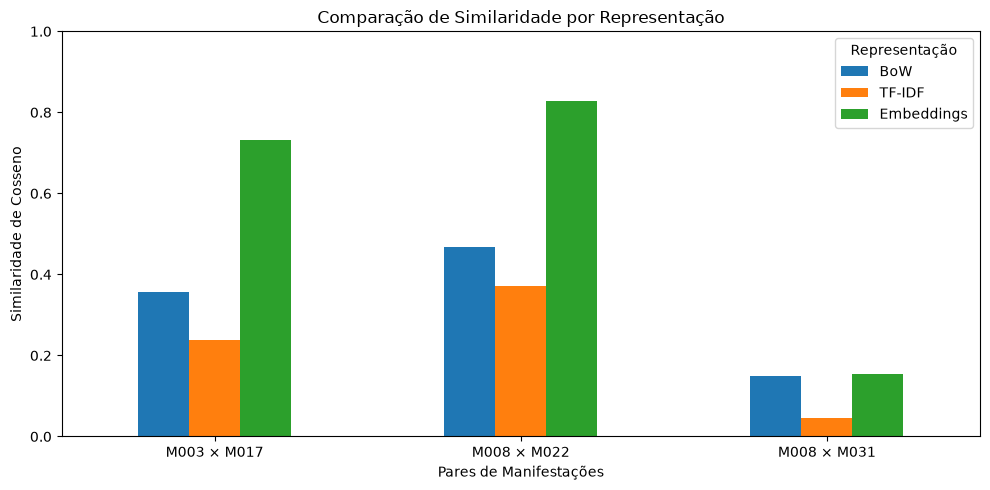

In [33]:
grafico = df_comparacao.set_index("Par")

ax = grafico.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Comparação de Similaridade por Representação")
ax.set_xlabel("Pares de Manifestações")
ax.set_ylabel("Similaridade de Cosseno")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Representação")
plt.tight_layout()
plt.show()

### Análise dos Resultados

Os resultados mostram diferenças importantes entre as três formas de representação textual. O Bag-of-Words (BoW) identificou alguma similaridade nos pares M003 × M017 e M008 × M022, porém sua análise depende diretamente da ocorrência de palavras em comum, sem considerar o contexto ou o significado dos termos. O TF-IDF apresentou comportamento semelhante, mas atribuiu pesos diferentes às palavras conforme sua relevância no corpus, resultando em similaridades de 0,239 e 0,371 para os dois pares semanticamente relacionados.

Os embeddings apresentaram maior capacidade de identificar a proximidade semântica entre manifestações escritas de maneiras diferentes. O par M003 × M017, que descreve problemas relacionados a buracos e asfalto danificado, alcançou similaridade de 0,732, enquanto M008 × M022, relacionado à falta de atendimento médico, atingiu 0,827. Em contraste, M008 × M031, que aborda assuntos distintos, apresentou similaridade de apenas 0,154.

Assim, BoW e TF-IDF são representações mais simples e interpretáveis, mas possuem limitações para reconhecer textos semanticamente equivalentes quando utilizam vocabulários diferentes. Os embeddings conseguem representar melhor relações de significado e contexto, embora dependam de modelos previamente treinados, demandem maior custo computacional e apresentem menor interpretabilidade direta dos vetores gerados. Para o cenário de triagem semântica da ouvidoria, os resultados indicam que os embeddings são especialmente úteis para identificar manifestações relacionadas mesmo quando os cidadãos descrevem um mesmo problema utilizando palavras diferentes.